/data/gravwav/koley/my_venv/lib/python3.10/site-packages/obspy/io/stationxml/core.py:91: UserWarning: The StationXML file has version 1.2, ObsPy can read versions (1.0, 1.1). Proceed with caution.
  warnings.warn("The StationXML file has version %s, ObsPy can "


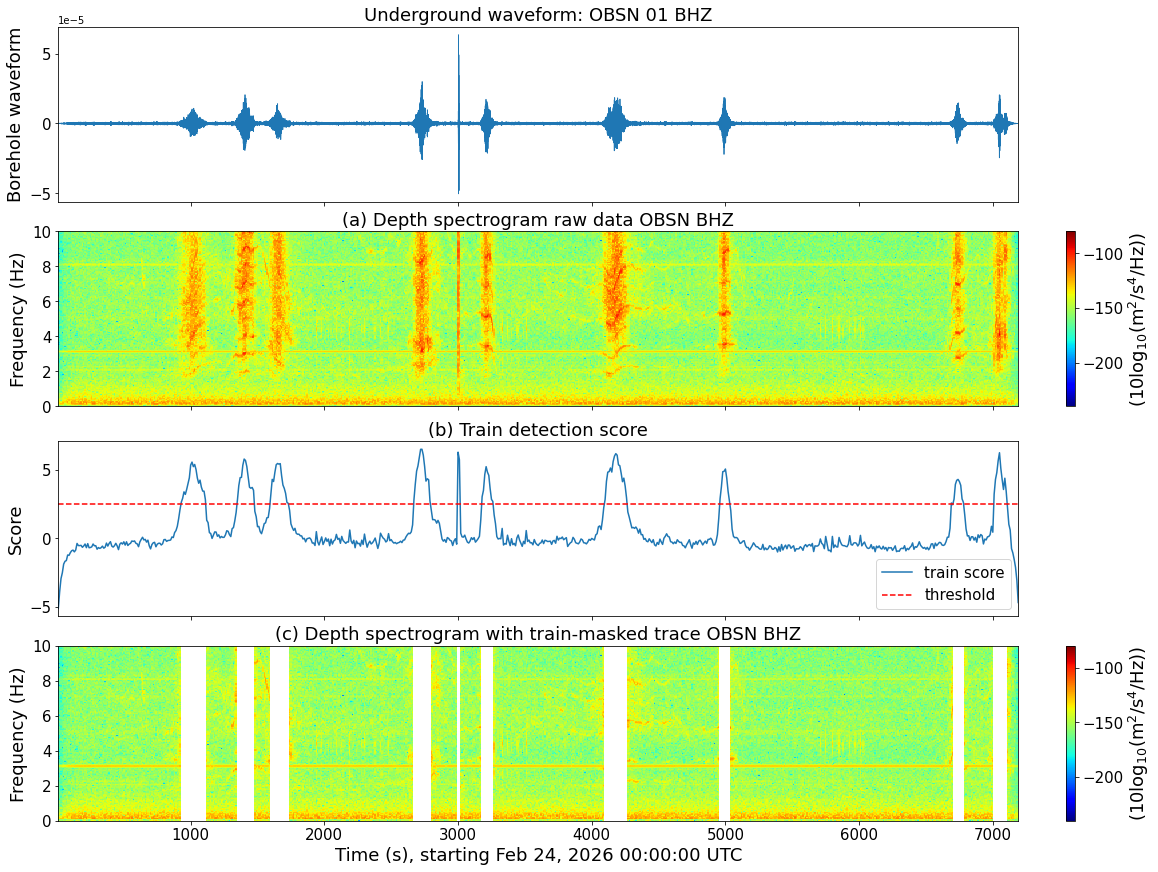

In [160]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sp
import datetime

from obspy import read_inventory, UTCDateTime
from obspy.clients.filesystem.sds import Client


# ============================================================
# Configuration
# ============================================================
rootP2 = '/dcache/etseis/et/EMR/Data'
archiveP2 = Client(rootP2)

respPath = '/dcache/etseis/et/EMR/Stations/Stations/NL.OBSN.xml'
invNow = read_inventory(respPath)

preFilt = [0.05, 0.1, 16, 18]

network = 'NL'
station = 'OBSN'
channel_surface = 'BHZ'
channel_borehole = 'BHZ'
loc_surface = '00'
loc_borehole = '01'

# one hour example
yearNow = 2026
julday = 55
hour0 = 0

A = datetime.datetime(yearNow, 1, 1) + datetime.timedelta(days=julday - 1)
Start = UTCDateTime(A.year, A.month, A.day, hour0, 0, 0)
End = Start + 7200


# ============================================================
# Helpers
# ============================================================
def fetch_corrected_trace(station, channel, location, starttime, endtime, use_prefilt):
    st = archiveP2.get_waveforms(
        station=station,
        channel=channel,
        network=network,
        location=location,
        starttime=starttime,
        endtime=endtime
    )
    if not st:
        return None, None

    tr = st[0].copy()
    tr.trim(starttime=starttime, endtime=endtime, pad=True, fill_value=0)

    remove_kwargs = dict(
        inventory=invNow,
        output='ACC',
        zero_mean=True,
        hide_sensitivity_mismatch_warning=True
    )
    if use_prefilt:
        remove_kwargs["pre_filt"] = preFilt

    tr.remove_response(**remove_kwargs)
    tr.trim(starttime=starttime, endtime=endtime, pad=True, fill_value=0)

    return tr.data.astype(float), float(tr.stats.sampling_rate)


def build_train_mask_from_spectrogram(x, fs,
                                      nperseg_sec=20,
                                      overlap_frac=0.5,
                                      f_band=(3, 15),
                                      z_thresh=2.5,
                                      min_duration_sec=20,
                                      pad_sec=20):
    """
    Detect train-contaminated spectrogram columns from underground data.
    Returns f, t, Sxx, score, mask
    """
    nperseg = int(nperseg_sec * fs)
    noverlap = int(nperseg * overlap_frac)

    f, t, Sxx = sp.spectrogram(
        x,
        fs=fs,
        window='hann',
        nperseg=nperseg,
        noverlap=noverlap,
        detrend='constant',
        scaling='density',
        mode='psd'
    )

    Sxx[Sxx <= 0] = np.finfo(float).tiny
    logS = np.log10(Sxx)

    # robust row-wise normalization
    row_med = np.median(logS, axis=1, keepdims=True)
    row_mad = np.median(np.abs(logS - row_med), axis=1, keepdims=True)
    row_mad[row_mad <= 0] = 1.0

    Z = (logS - row_med) / row_mad

    # train-sensitive frequency band
    band = (f >= f_band[0]) & (f <= f_band[1])
    if not np.any(band):
        raise ValueError("Chosen frequency band does not overlap spectrogram frequencies.")

    # score per time column: median z-score in the band
    score = np.median(Z[band, :], axis=0)

    # threshold
    mask = score > z_thresh

    # remove too-short detections
    dt = np.median(np.diff(t))
    min_cols = max(1, int(np.round(min_duration_sec / dt)))
    pad_cols = max(0, int(np.round(pad_sec / dt)))

    # connected-component cleanup
    mask_clean = mask.copy()
    idx = np.where(mask)[0]
    if len(idx) > 0:
        groups = np.split(idx, np.where(np.diff(idx) > 1)[0] + 1)
        mask_clean[:] = False
        for g in groups:
            if len(g) >= min_cols:
                i0 = max(0, g[0] - pad_cols)
                i1 = min(len(mask), g[-1] + pad_cols + 1)
                mask_clean[i0:i1] = True

    return f, t, Sxx, score, mask_clean


# ============================================================
# Load data
# ============================================================
x_bh, fs_bh = fetch_corrected_trace(
    station=station,
    channel=channel_borehole,
    location=loc_borehole,
    starttime=Start,
    endtime=End,
    use_prefilt=True
)

x_sf, fs_sf = fetch_corrected_trace(
    station=station,
    channel=channel_surface,
    location=loc_surface,
    starttime=Start,
    endtime=End,
    use_prefilt=True
)

if x_bh is None:
    raise RuntimeError("No underground data found.")
if x_sf is None:
    raise RuntimeError("No surface data found.")

if fs_bh != fs_sf:
    raise RuntimeError("Sampling rates do not match.")

fs = fs_bh
t_wave = np.arange(len(x_bh)) / fs

# ============================================================
# Detect trains from underground spectrogram
# ============================================================
f, t_spec, Sxx_bh, score, mask = build_train_mask_from_spectrogram(
    x_bh,
    fs,
    nperseg_sec=20,
    overlap_frac=0.5,
    f_band=(2,8),
    z_thresh=2.5,
    min_duration_sec=20,
    pad_sec=0
)

# masked spectrogram for display
Sxx_masked = Sxx_bh.copy()
Sxx_masked[:, mask] = np.nan

# surface spectrogram for optional comparison
_, _, Sxx_sf = sp.spectrogram(
    x_sf,
    fs=fs,
    window='hann',
    nperseg=int(20 * fs),
    noverlap=int(10 * fs),
    detrend='constant',
    scaling='density',
    mode='psd'
)
Sxx_sf[Sxx_sf <= 0] = np.finfo(float).tiny
Sxx_sf_masked = Sxx_sf.copy()
Sxx_sf_masked[:, mask] = np.nan

# ============================================================
# Plot
# ============================================================
fig, axs = plt.subplots(
    4, 1,
    figsize=(16, 12),   # wider figure
    sharex=True,
    constrained_layout=True
)

# 1) underground waveform
axs[0].plot(t_wave, x_bh, lw=0.8)
axs[0].set_ylabel('Borehole waveform',fontsize=18)
axs[0].set_title(f'Underground waveform: {station} {loc_borehole} {channel_borehole}',fontsize=18)
axs[0].tick_params(axis='both', labelsize=15)

# 2) underground spectrogram
pcm1 = axs[1].pcolormesh(
    t_spec, f, 10 * np.log10(Sxx_bh),
    shading='auto',
    cmap='jet'
)
pcm1.set_clim(-240, -80)

axs[1].set_ylabel('Frequency (Hz)',fontsize=18)
axs[1].set_ylim(0,10)
axs[1].set_title('(a) Depth spectrogram raw data '+ station + ' ' + channel_borehole, fontsize=18)
axs[1].tick_params(axis='both', labelsize=15)
cbar = fig.colorbar(pcm1, ax=axs[1], label='dB')
cbar.set_label(r'($10\log_{10}(\mathrm{m}^2/\mathrm{s}^4/\mathrm{Hz}$))', fontsize=18)
cbar.ax.tick_params(labelsize=15)

# 3) train score and mask
axs[2].plot(t_spec, score, lw=1.5, label='train score')
axs[2].axhline(2.5, color='r', ls='--', label='threshold')
axs[2].set_ylabel('Score',fontsize=18)
axs[2].set_title('(b) Train detection score',fontsize=18)
axs[2].tick_params(axis='both', labelsize=15)
axs[2].legend(fontsize=15)

# 4) masked underground spectrogram
pcm2 = axs[3].pcolormesh(
    t_spec, f, 10 * np.log10(Sxx_masked),
    shading='auto',
    cmap='jet'
)
pcm2.set_clim(-240, -80)

axs[3].set_ylabel('Frequency (Hz)',fontsize = 18)
axs[3].set_xlabel('Time (s), starting Feb 24, 2026 00:00:00 UTC',fontsize = 18)
axs[3].set_ylim(0,10)
axs[3].set_title('(c) Depth spectrogram with train-masked trace '+ station + ' ' + channel_borehole,fontsize=18)
axs[3].tick_params(axis='both', labelsize=15)
cbar = fig.colorbar(pcm2, ax=axs[3], label='dB')
cbar.set_label(r'($10\log_{10}(\mathrm{m}^2/\mathrm{s}^4/\mathrm{Hz}$))', fontsize=18)
cbar.ax.tick_params(labelsize=15)

"""
# 5) surface spectrogram
pcm3 = axs[4].pcolormesh(
    t_spec, f, 10 * np.log10(Sxx_sf_masked),
    shading='auto',
    cmap='jet'
)
pcm3.set_clim(-240, -80)
axs[4].set_ylabel('Frequency (Hz)',fontsize=18)
axs[4].set_xlabel('Time (s)',fontsize=18)
axs[4].set_ylim(0.1, 18)
axs[4].set_title('Surface spectrogram with underground-derived train mask',fontsize=18)
axs[4].tick_params(axis='both', labelsize=15)
cbar = fig.colorbar(pcm3, ax=axs[4], label='dB')
cbar.set_label('dB', fontsize=18)
cbar.ax.tick_params(labelsize=15)
"""
# set common x-limits so all panels fill the width
axs[3].set_xlim(t_spec[0], t_spec[-1])
#axs[4].set_xlim(8000,8500)

plt.show()

17


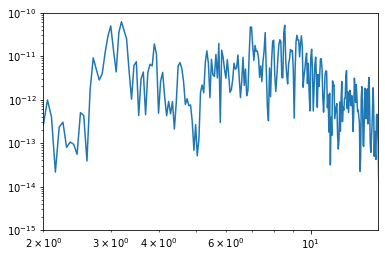

In [109]:
tInd = np.where(t_spec>170)[0][0]
plt.loglog(f,Sxx_bh[:,(22)])
plt.xlim(2,15)
plt.ylim(10**-15,10**-10)
print(tInd)